In [115]:
import healpy as hp 
import pylab as pl 
import numpy as np 

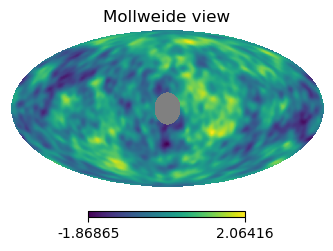

In [156]:
nside=256
np.random.seed(123349) 
alm =hp.synalm (pl.arange(1,3*nside)**-2. )
alms= hp.almxfl(alm, hp.gauss_beam(fwhm= pl.radians(5)) ) 
m= hp.alm2map(alms, nside=nside) 
#m =pl.arange(hp.nside2npix(nside ) ,dtype=float ) 
vec= hp.ang2vec(theta=pl.pi/2,phi= 0) 
morig= m.copy() 
hole = hp.query_disc(nside=nside, vec=vec , radius= pl.radians(15)) 
m[hole] = pl.nan #np.random.normal(loc= morig.mean(), scale=morig.std(),size=hole.size) 
hp.mollview(m,sub=121) 

theta,phi = hp.pix2ang(ipix=hole, nside=nside, lonlat=False)
neighbs = hp.get_all_neighbours(nside,theta,phi, lonlat=False)



In [157]:

c=0
while True:
    tmp = m[hole]
    for jj, ipix in enumerate(hole) : 
            
        fill_neighb = ~pl.ma.masked_invalid(m[neighbs[:, jj]] ).mask 
        m[ipix] = pl.mean(m[neighbs[fill_neighb, jj] ])
    if pl.allclose(m[hole], tmp,atol=1e-4  ): break 
    c+=1

    if c%50==0: 
        print(c, pl.linalg.norm(m[hole] - tmp ))  
        #pl.figure() 
        #hp.mollview(m-morig,sub=122) 
    #if c>500: break 
    
        



50 0.3141245200996842
100 0.20217150273161713
150 0.1550535976658934
200 0.1266001678372996
250 0.10649155272497014
300 0.09105964425152087
350 0.07864758942874191
400 0.06837990228713112
450 0.05973647502214315
500 0.05237811833474622
550 0.046066606379638234
600 0.04062480702352075
650 0.035915316774921796
700 0.03182822025584606
750 0.028273617048792776
800 0.025176780763687893
850 0.022474852752807827
900 0.020114479659277228
950 0.018050061767459515
1000 0.016242415493249614
1050 0.014657728351246383
1100 0.013266727618310464
1150 0.012044009405152234
1200 0.010967490607325749
1250 0.010017956351669272
1300 0.009178682372455145
1350 0.008435116552978877
1400 0.007774607416140911
1450 0.007186170085532923
1500 0.0066602824180307385
1550 0.0061887057660026555
1600 0.005764326233570649
1650 0.005381013388488779


1670


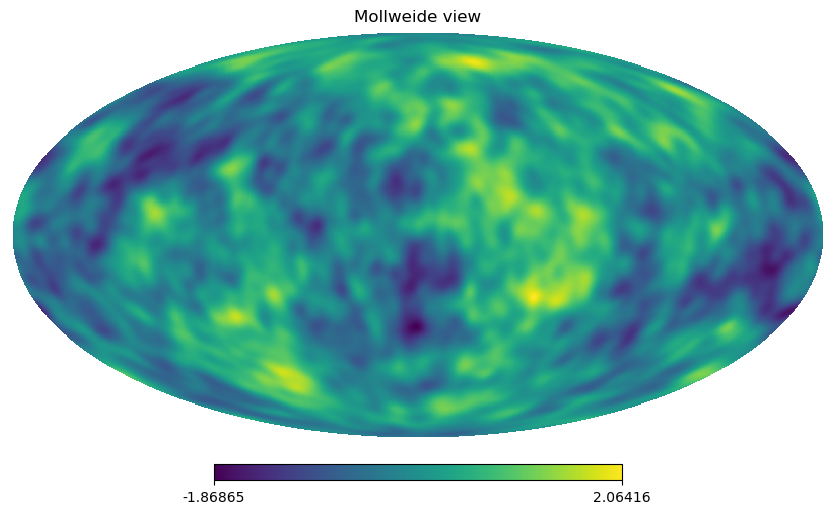

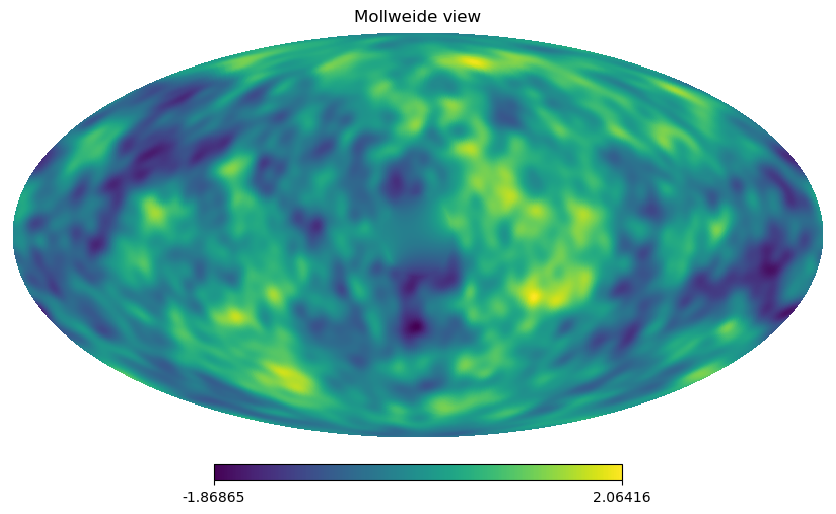

In [159]:
hp.mollview(morig )
hp.mollview(m )
print(c) 